# About the Database

The dataset used in this project contains information about movies and TV shows available on Netflix. It consists of **8,807 records** and **12 columns**, each representing attributes such as title, director, cast, release year, and genre.

**Structure of the Dataset**

| Column Name   | Description |
|----------------|-------------|
| **show_id** | Unique identifier for each title. |
| **type** | Specifies whether the title is a *Movie* or a *TV Show*. |
| **title** | Name of the show or movie. |
| **director** | Name of the director(s) of the title (may contain missing values). |
| **cast** | List of main actors or actresses involved in the title. |
| **country** | Country or countries where the title was produced. |
| **date_added** | Date when the title was added to Netflix. |
| **release_year** | The year the title was originally released. |
| **rating** | Maturity rating (e.g., PG, R, TV-MA). |
| **duration** | For movies, the duration in minutes; for TV shows, the number of seasons. |
| **listed_in** | Categories or genres assigned to the title. |
| **description** | Brief summary or synopsis ** the title.**|

**Data Source**

[Kaggle - Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)


***

# Table of Contents
1. [Explore Data](#1.Explore-Data)
2. [Univariate Analysis](#2.Univariate-Analysis)
3. [Multivariate Analysis](#3.Multivariate-Analysis)
4. [Linear Regression](#4.Linear-Regression)


***

# 1.Explore Data

In [718]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [719]:
df = pd.read_csv(r"C:\Users\jigme\Projects\Netflix EDA\netflix_movies (1).csv")
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2166,s2167,Movie,A Go! Go! Cory Carson Summer Camp,"Stanley Moore, Alex Woo","Alan C. Lim, Smith Foreman, Abigail Vibat, Pfi...",NaN,"August 4, 2020",2020,TV-Y,21 min,Children & Family Movies,Cory's spending the summer at Camp Friendship ...
6211,s6212,Movie,Bad Boys,Michael Bay,"Will Smith, Martin Lawrence, Téa Leoni, Tchéky...",United States,"October 1, 2019",1995,R,119 min,"Action & Adventure, Comedies","In this fast-paced actioner, two Miami narcoti..."
7446,s7447,TV Show,Mere Papa Hero Hiralal,NaN,"Sarwar Ahuja, Riva Arora",NaN,"May 1, 2018",2018,TV-14,1 Season,"International TV Shows, TV Dramas",A simple auto-rickshaw driver on the streets o...
2478,s2479,Movie,Modest Heroes: Ponoc Short Films Theatre,"Hiromasa Yonebayashi, Yoshiyuki Momose, Akihik...","Fumino Kimura, Rio Suzuki, Machiko Ono, Sota S...",Japan,"May 22, 2020",2018,PG,54 min,"Anime Features, Children & Family Movies",Two underwater siblings surviving on their own...
4130,s4131,TV Show,Tayee,NaN,"Amr Youssef, Amr Abdel Guelil, Saba Mubarak",Egypt,"February 5, 2019",2018,TV-MA,1 Season,"International TV Shows, TV Dramas",An Egyptian doctor becomes a police informant ...


In [720]:
# row and columns 
df.shape

(8807, 12)

In [721]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [722]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [723]:
df.describe(include = 'object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,3207,1793,362,4


In [724]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [725]:
# no duplicates
df.duplicated().sum()

0

**Cleaning missing values**

In [727]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Not Available')

# Dropping rows with missing, date_added, duration, and rating
df = df.dropna()

In [728]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

**Converting column 'date_added' to a Pandas datetime obj and extracting Year, month and day**

In [730]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df['day'] = df['date_added'].dt.day
df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year
df.drop('date_added', axis = 1, inplace =True)

In [731]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
release_year     0
rating           0
duration         0
listed_in        0
description      0
day             88
month           88
year            88
dtype: int64

In [732]:
df.dropna(inplace = True)

In [733]:
df.nunique()

show_id         8702
type               2
title           8699
director        4523
cast            7602
country          746
release_year      74
rating            14
duration         219
listed_in        509
description     8671
day               31
month             12
year              14
dtype: int64

**Converting 'type' and 'rating' to pandas category datatype** 

In [735]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

In [736]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8702 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       8702 non-null   object  
 1   type          8702 non-null   category
 2   title         8702 non-null   object  
 3   director      8702 non-null   object  
 4   cast          8702 non-null   object  
 5   country       8702 non-null   object  
 6   release_year  8702 non-null   int64   
 7   rating        8702 non-null   category
 8   duration      8702 non-null   object  
 9   listed_in     8702 non-null   object  
 10  description   8702 non-null   object  
 11  day           8702 non-null   float64 
 12  month         8702 non-null   float64 
 13  year          8702 non-null   float64 
dtypes: category(2), float64(3), int64(1), object(8)
memory usage: 901.6+ KB


**Splitting by commas for 'director', 'cast', 'country', and 'listed_in'**

In [738]:
df['director'] = df['director'].str.split(', ')
df['cast'] = df['cast'].str.split(', ')
df['country'] = df['country'].str.split(', ')
df['listed_in'] = df['listed_in'].str.split(', ')

**Cleaning Strings**

In [740]:
df['title'] = df['title'].str.title()
df['description'] = df['description'].str.strip()

In [741]:
df.sample(7)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
2707,s2708,Movie,Angel Has Fallen,[Ric Roman Waugh],"[Gerard Butler, Morgan Freeman, Nick Nolte, Da...",[United States],2019,R,121 min,[Action & Adventure],Secret Service agent Mike Banning is caught in...,4.0,4.0,2020.0
565,s566,TV Show,Bureau Of Magical Things,[Not Available],"[Kimie Tsukakoshi, Elizabeth Cullen, Mia Milne...","[Australia, Germany]",2020,TV-G,1 Season,"[International TV Shows, Kids' TV, TV Mysteries]",When a teen accidentally discovers an enchante...,1.0,7.0,2021.0
5897,s5898,Movie,Cowspiracy: The Sustainability Secret,"[Kip Andersen, Keegan Kuhn]",[Kip Andersen],[United States],2014,TV-PG,90 min,[Documentaries],Learn how factory farming is decimating the pl...,15.0,9.0,2015.0
4061,s4062,Movie,Sarvam Thaala Mayam (Tamil Version),[Rajiv Menon],"[G.V. Prakash Kumar, Nedumudi Venu, Aparna Bal...",[Not Available],2018,TV-14,131 min,"[Dramas, International Movies, Music & Musicals]",An aspiring musician battles age-old caste div...,1.0,3.0,2019.0
5912,s5913,Movie,The Other One: The Long Strange Trip Of Bob Weir,[Mike Fleiss],[Bob Weir],[United States],2015,TV-14,84 min,"[Documentaries, Music & Musicals]",This chronicle of Bob Weir highlights his brot...,22.0,5.0,2015.0
6055,s6056,Movie,A Scandall,[Ishaan Trivedi],"[Johnny Baweja, Reeth Mazumder, Manav Kaul, Ta...",[India],2016,TV-MA,108 min,"[International Movies, Thrillers]",A film school graduate is interested in making...,15.0,10.0,2017.0
1221,s1222,Movie,Generasi 90An: Melankolia,[Mohammad Irfan Ramly],"[Ari Irham, Aghniny Haque, Taskya Namya, Marce...",[Indonesia],2020,TV-14,94 min,"[Dramas, International Movies]","After the devastating loss of a loved one, Abb...",11.0,3.0,2021.0


***

# 2.Univariate Analysis

**1.What is the range of year added in the dataset?**

In [745]:
print(f"Titles were added to the data set from {min(df['year']):.0f} to {max(df['year']):.0f}")


Titles were added to the data set from 2008 to 2021


**2.Which type of content is more prevalent in Netflix: Movies or TV Shows?**

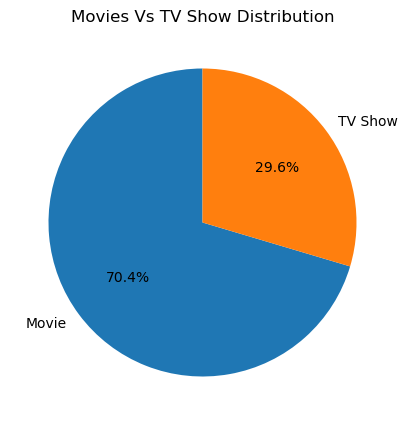

type
Movie      6126
TV Show    2576
Name: count, dtype: int64

In [747]:
plt.figure(figsize = (5,5))
count = df['type'].value_counts()
plt.pie(count,labels = count.index, 
        autopct='%1.1f%%', startangle=90)
plt.title('Movies Vs TV Show Distribution')
plt.show()
count

**3.Top 20 Directors by Number of Titles**

In [749]:
df_1 = df.copy()

In [750]:
df_1 = df_1.explode('director')
df_1 = df_1[df_1['director']!='Not Available']
top_directors = df_1['director'].value_counts().head(10)

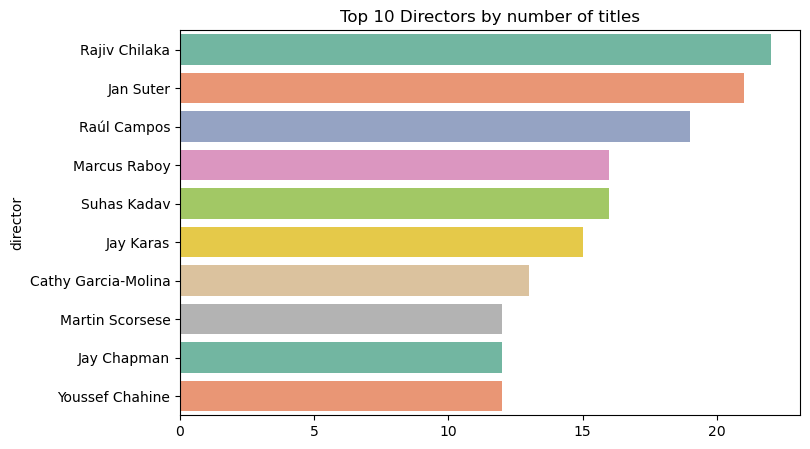

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: count, dtype: int64

In [751]:
plt.figure(figsize=(8,5))
sns.barplot(y = top_directors.index, x = top_directors.values,
            hue = top_directors.index, legend=False, palette = 'Set2')
plt.title('Top 10 Directors by number of titles')
plt.show()
top_directors

**4.Top 10 Cast members**

In [753]:
df_1 = df.copy()

In [754]:
df_1 = df_1.explode('cast')
df_1 = df_1[df_1['cast'] != 'Not Available']
top_cast = df_1['cast'].value_counts().head(10)

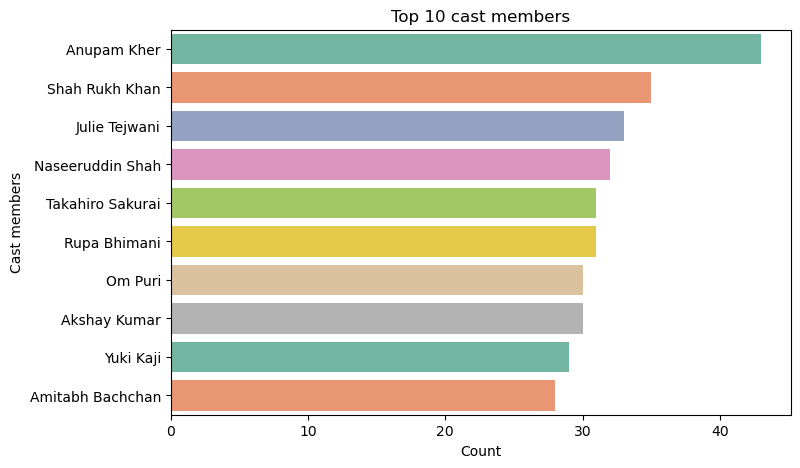

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    31
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

In [755]:
plt.figure(figsize=(8,5))
sns.barplot(y = top_cast.index, x = top_cast.values, 
            hue = top_cast.index, palette = 'Set2')
plt.title('Top 10 cast members')
plt.xlabel('Count')
plt.ylabel('Cast members')
plt.show()

top_cast

**5.Which Country produces the most content?**

In [757]:
df_1 = df.copy()

In [758]:
df_1 = df_1.explode('country')
df_1 = df_1[df_1['country'] != 'Not Available']
top_countries = df_1['country'].value_counts().head(10)

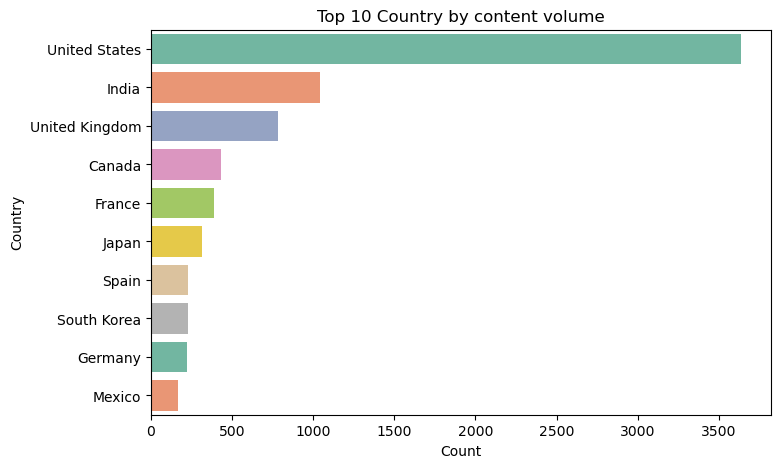

country
United States     3639
India             1045
United Kingdom     785
Canada             432
France             389
Japan              313
Spain              228
South Korea        226
Germany            225
Mexico             169
Name: count, dtype: int64

In [759]:
plt.figure(figsize=(8,5))
sns.barplot(y = top_countries.index, x = top_countries.values,
           hue = top_countries.index, palette = 'Set2')
plt.title('Top 10 Country by content volume')
plt.ylabel('Country')
plt.xlabel('Count')
plt.show()

top_countries

**6.Distribution of titles by rating.**

In [761]:
ratings_order = df['rating'].value_counts().index
ratings = df['rating'].value_counts()

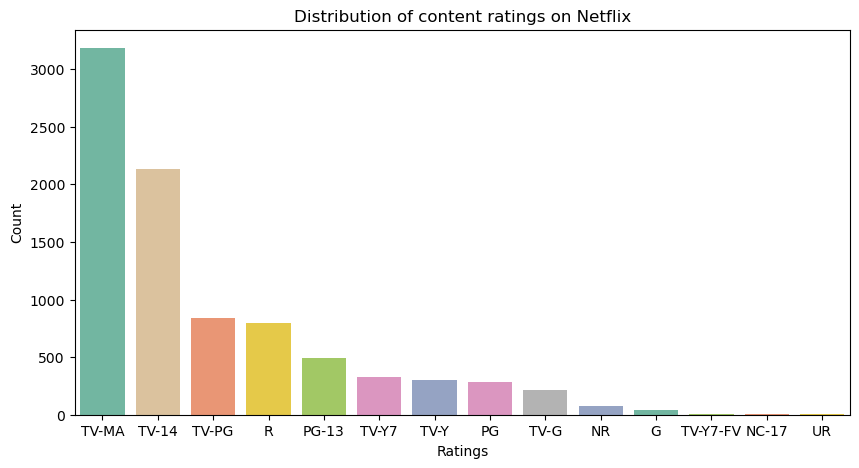

rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

In [762]:
plt.figure(figsize=(10,5))
sns.barplot(x = ratings.index, y = ratings.values,
            hue = ratings.index, order = ratings_order, palette = 'Set2')
plt.title('Distribution of content ratings on Netflix')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()
ratings

**7.What are the Most Popular Genre in Netflix?**

In [764]:
df_1 = df.copy()

In [765]:
df_1 = df_1.explode('listed_in')
top_genre = df_1['listed_in'].value_counts().head(10)

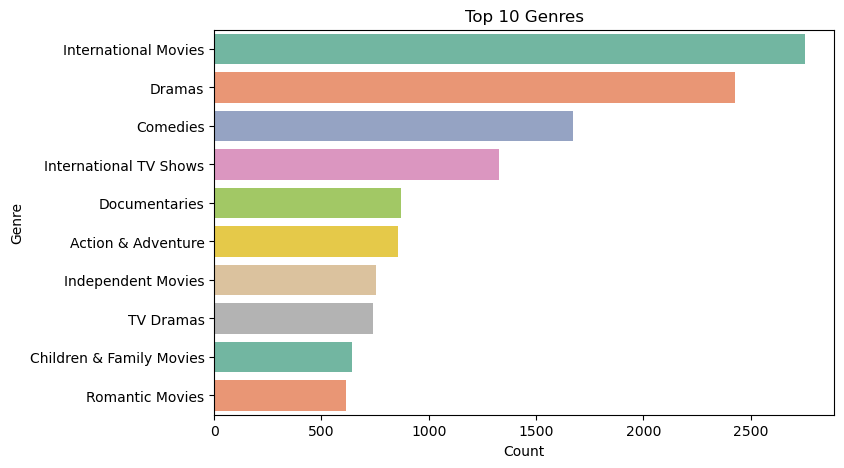

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1327
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [766]:
plt.figure(figsize=(8,5))
sns.barplot(y = top_genre.index, x = top_genre.values, 
            hue = top_genre.index, palette = 'Set2')
plt.title('Top 10 Genres')
plt.ylabel('Genre')
plt.xlabel('Count')
plt.show()
top_genre

**8.What is the average Movie Duration?**

In [768]:
# filter only movies and change the string to float data type 
movie_duration = df.loc[df['type']=='Movie']['duration'] \
                   .str.replace(' min','').astype(float).reset_index(drop=True)
avg_duration = movie_duration.mean()
print(f"The average movie duration is {avg_duration:.2f} minutes.")

The average movie duration is 99.58 minutes.


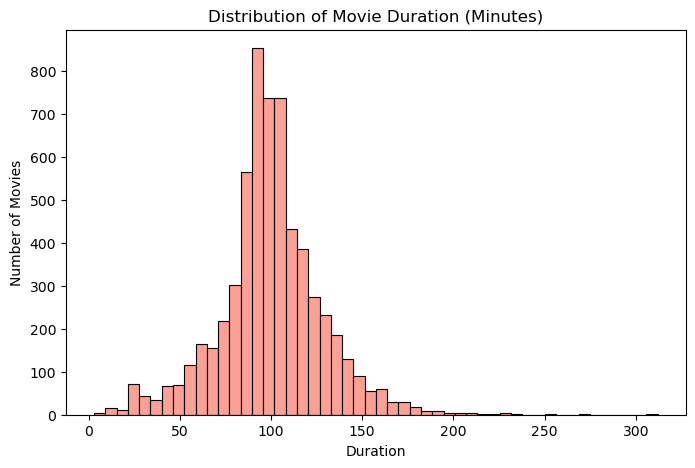

In [769]:
plt.figure(figsize=(8,5))
sns.histplot(movie_duration, bins = 50, color = 'salmon')
plt.title('Distribution of Movie Duration (Minutes)')
plt.xlabel('Duration')
plt.ylabel('Number of Movies')
plt.show()

**9.What are the longest Movies in Netflix?**

In [771]:
movie_df = df.loc[df['type']=='Movie'].copy()

In [772]:
movie_df['movie_duration'] = movie_duration.values
longest_movies = movie_df.sort_values(by = 'movie_duration', 
                                      ascending = False).reset_index(drop=True).head(10).copy()

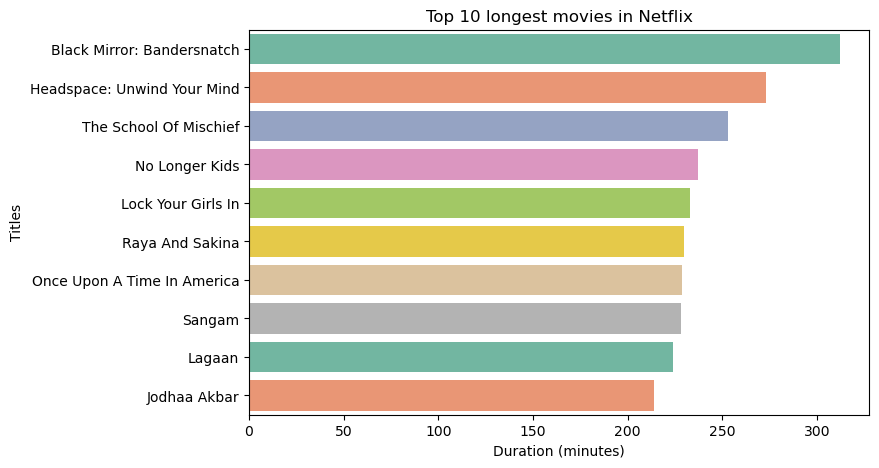

,title,movie_duration
0,Black Mirror: Bandersnatch,312.0
1,Headspace: Unwind Your Mind,273.0
2,The School Of Mischief,253.0
3,No Longer Kids,237.0
4,Lock Your Girls In,233.0
5,Raya And Sakina,230.0
6,Once Upon A Time In America,229.0
7,Sangam,228.0
8,Lagaan,224.0
9,Jodhaa Akbar,214.0


In [773]:
plt.figure(figsize=(8,5))
sns.barplot(y = longest_movies['title'], x = longest_movies['movie_duration'],
            hue = longest_movies['title'], palette = 'Set2')
plt.title('Top 10 longest movies in Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Titles')
plt.show()
longest_movies[['title', 'movie_duration']]

In [774]:
print(f"The longest movie in Netflix is {longest_movies['title'][0]}.")

The longest movie in Netflix is Black Mirror: Bandersnatch.


**10.How many seasons do TV Shows have in Average?**

In [776]:
show_duration = df.loc[df['type'] == 'TV Show']['duration'].str.replace('Seasons', 'Season')
show_duration = show_duration.str.replace(' Season','').astype(int).reset_index(drop=True)
avg_show_duration = show_duration.mean()
print(f"The average length of TV Show is {avg_show_duration:.2f} Season")

The average length of TV Show is 1.69 Season


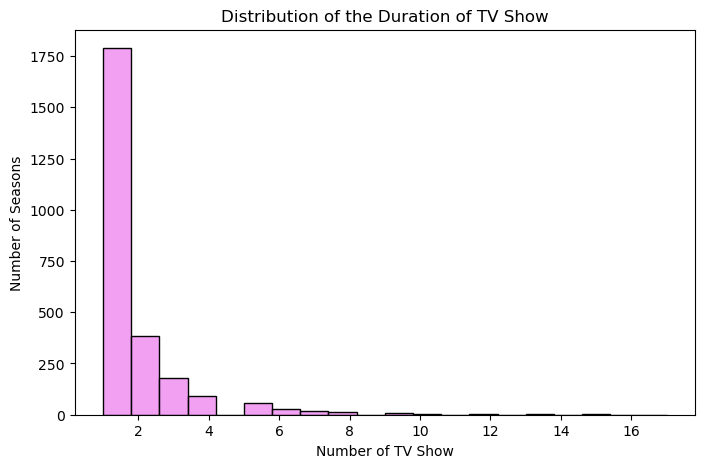

duration
1     1789
2      384
3      178
4       89
5       55
6       30
7       18
8       13
9        8
10       5
13       2
15       2
12       2
17       1
Name: count, dtype: int64

In [777]:
plt.figure(figsize=(8,5))
sns.histplot(show_duration, bins = 20, color = 'violet')
plt.title('Distribution of the Duration of TV Show')
plt.xlabel('Number of TV Show')
plt.ylabel('Number of Seasons')
plt.show()
show_duration.value_counts()

**11.What are the longest running TV Shows in Netflix?**

In [779]:
show_df = df.loc[df['type'] == 'TV Show'].copy()

In [780]:
show_df['show_duration'] = show_duration.values
longest_show = show_df[['title','show_duration']].sort_values(
                        'show_duration',ascending=False).head(10).reset_index(drop=True)

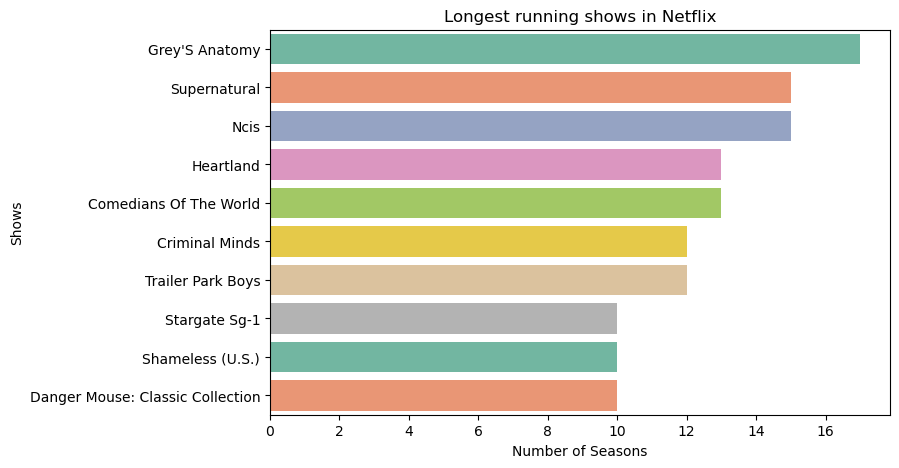

,title,show_duration
0,Grey'S Anatomy,17
1,Supernatural,15
2,Ncis,15
3,Heartland,13
4,Comedians Of The World,13
5,Criminal Minds,12
6,Trailer Park Boys,12
7,Stargate Sg-1,10
8,Shameless (U.S.),10
9,Danger Mouse: Classic Collection,10


In [781]:
plt.figure(figsize=(8,5))
sns.barplot(x = longest_show['show_duration'], y = longest_show['title'],
           hue = longest_show['title'], palette = 'Set2')
plt.title('Longest running shows in Netflix')
plt.xlabel('Number of Seasons')
plt.ylabel('Shows')
plt.show()
longest_show

**12.Which month has the most content added to Netflix?**

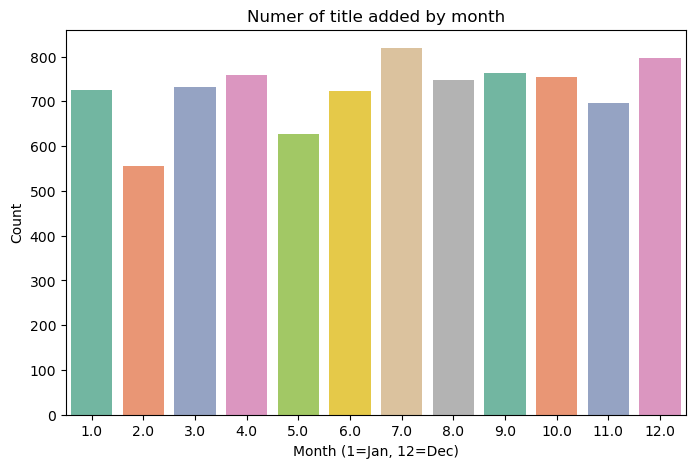

In [783]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'month', data = df, hue = 'month', legend=False, palette = 'Set2')
plt.title('Numer of title added by month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Count')
plt.show()


**13.Which day has the most content added to Netflix?**

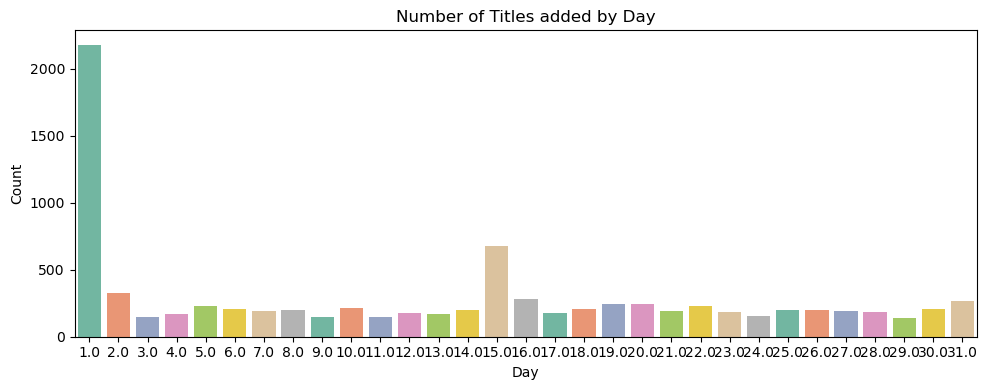

In [785]:
plt.figure(figsize=(10,4))
sns.countplot(x = 'day', data = df, hue = 'day', legend=False, palette = 'Set2')
plt.title('Number of Titles added by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

***

# 3.Multivariate Analysis

**1.For each type of content what are the most common content ratings?**

In [789]:
order_desc = df['rating'].value_counts().index

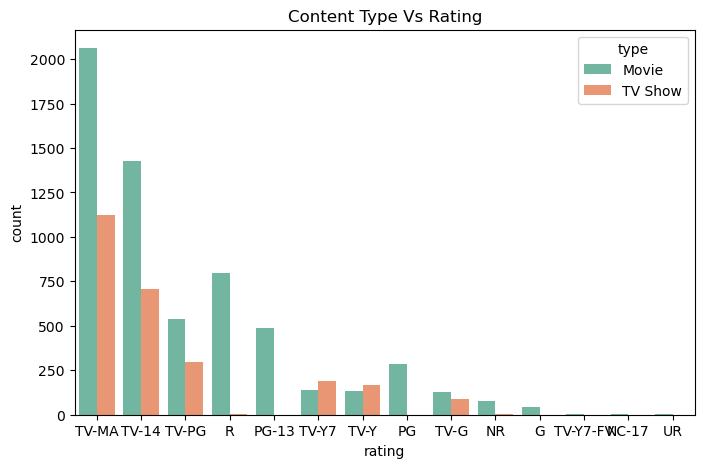

In [790]:
plt.figure(figsize=(8,5))
sns.countplot(x ='rating', hue = 'type', data = df, 
              palette = 'Set2', order = order_desc)
plt.title('Content Type Vs Rating')
plt.show()

**2.Movies vs TV Shows added on Netflix over the years.**

In [792]:
type_year_count = df.groupby(['year','type'], observed = True).size().unstack()

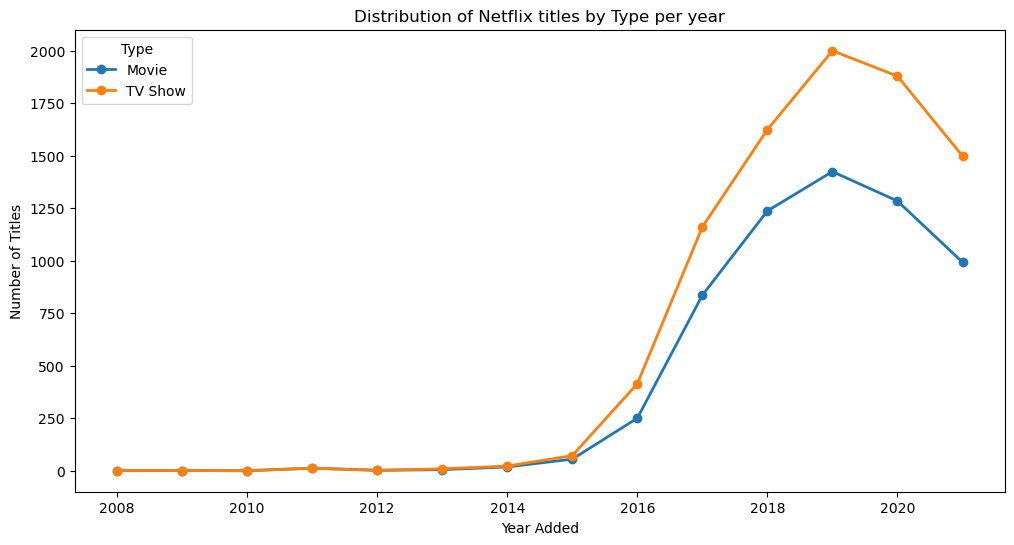

type,Movie,TV Show
year,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,4.0
2014.0,19.0,4.0
2015.0,56.0,17.0
2016.0,251.0,164.0


In [793]:
type_year_count.plot(kind='line', marker = 'o', stacked=True,
                     figsize = (12,6), linewidth=2,
                     color=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Netflix titles by Type per year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.show()
type_year_count 

**3.What are the most produced genres over the years?**

In [795]:
df_1 = df.copy()

In [796]:
df_exploded = df_1.explode('listed_in')
top_genre_cnt = df_exploded.groupby(['release_year', 
                                     'listed_in']).size().reset_index(name='count')
top_genre = top_genre_cnt.groupby('listed_in')['count'] \
                         .sum().sort_values(ascending=False).head(10).index
top_genre_year = top_genre_cnt[top_genre_cnt['listed_in'].isin(top_genre)]

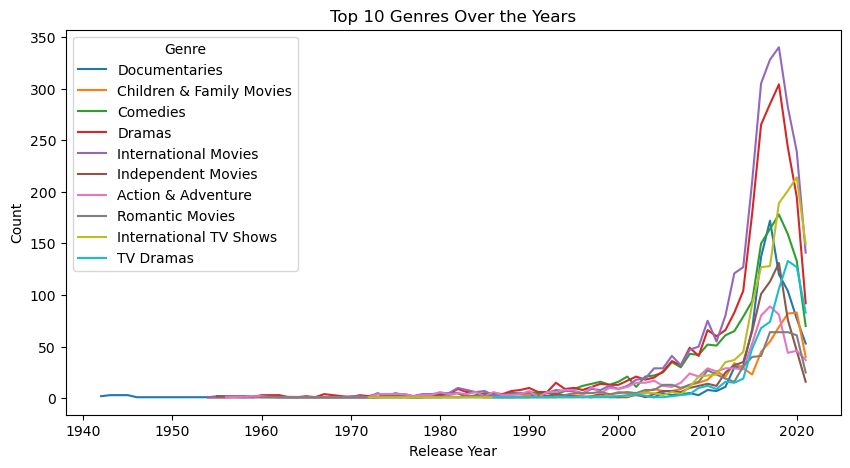

In [797]:
plt.figure(figsize=(10,5))
sns.lineplot(x = 'release_year', y = 'count', hue = 'listed_in', data= top_genre_year)
plt.title('Top 10 Genres Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title = 'Genre')
plt.show()

**4.What are the most popular Genre by country?**

In [799]:
df_1 = df.copy()

In [800]:
df_exploded = df_1.explode('listed_in').explode('country')
genre_country_cnt = df_exploded.groupby(['listed_in', 'country']) \
                               .size().reset_index(name='count')
top_genre_by_country = genre_country_cnt.loc[genre_country_cnt \
                                        .groupby('country')['count'].idxmax()] \
                                        .reset_index(drop=True).sort_values(by = 'count', ascending=False)

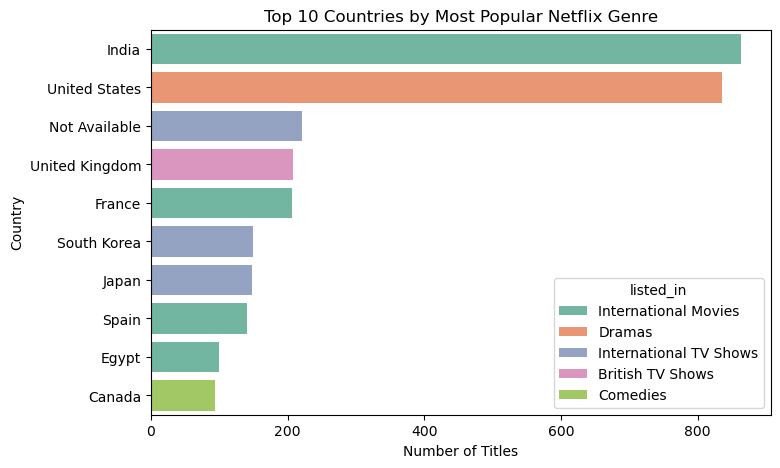

,listed_in,country,count
47,International Movies,India,864
120,Dramas,United States,835
81,International TV Shows,Not Available,221
118,British TV Shows,United Kingdom,208
38,International Movies,France,207
104,International TV Shows,South Korea,149
55,International TV Shows,Japan,148
106,International Movies,Spain,140
35,International Movies,Egypt,99
22,Comedies,Canada,94


In [801]:
plt.figure(figsize=(8,5))
# top 10 by counts
top_10 = top_genre_by_country.head(10)
sns.barplot(x = 'count', y = 'country', hue = 'listed_in', 
            data = top_10, palette = 'Set2')
plt.title('Top 10 Countries by Most Popular Netflix Genre')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()
top_genre_by_country.head(10) 

**5.How does the Duration of Movies vary by Genre?**

In [803]:
df_1  = movie_df.copy()

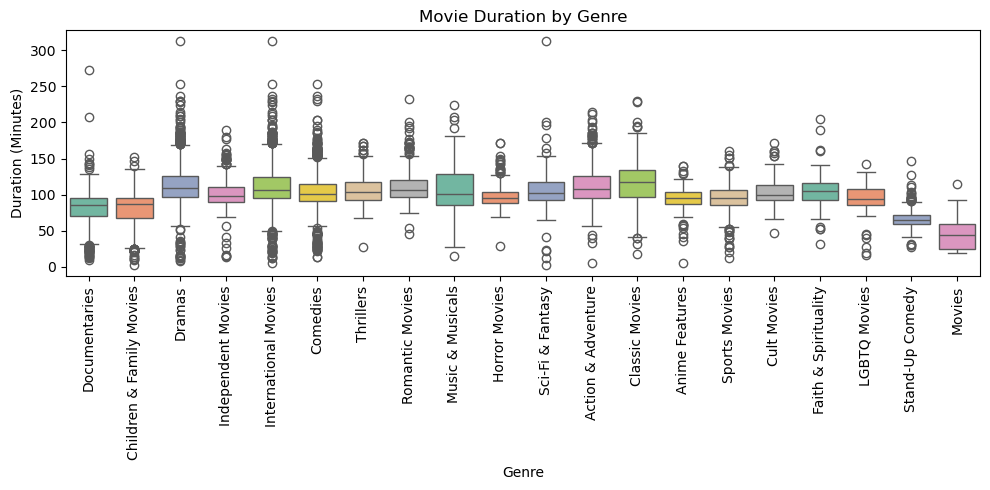

In [804]:
plt.figure(figsize = (10,5))
df_exploded = df_1.explode('listed_in')
sns.boxplot(data = df_exploded, x = 'listed_in', hue = 'listed_in', y = 'movie_duration', palette = 'Set2')
plt.title('Movie Duration by Genre')
plt.xlabel('Genre')
plt.xticks(rotation=90)
plt.ylabel('Duration (Minutes)')
plt.tight_layout()
plt.show()

**6.How does length of TV Shows vary by Genre?**

In [806]:
df_1 = show_df.copy()

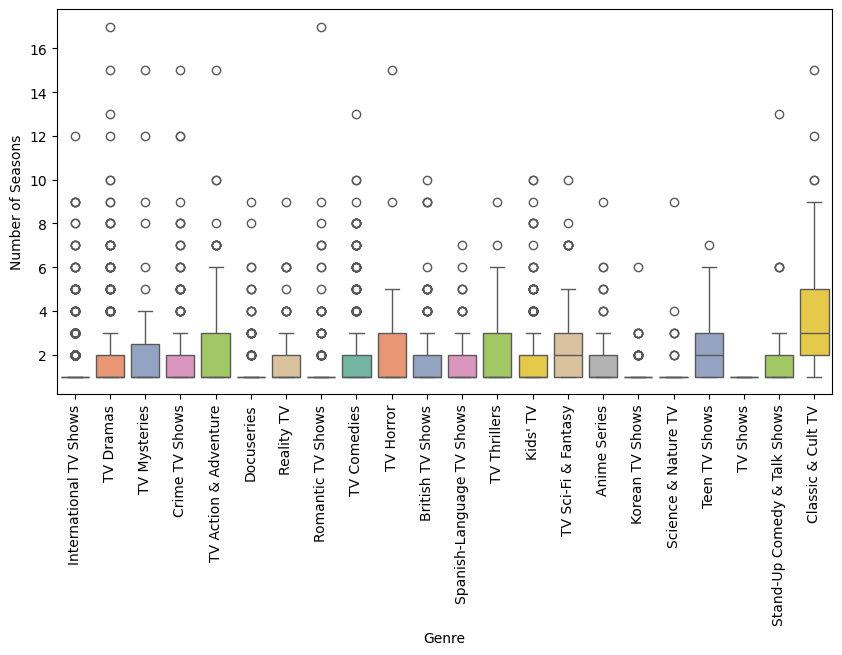

In [807]:
plt.figure(figsize = (10,5))
df_exploded = df_1.explode('listed_in')
sns.boxplot(data = df_exploded, x = 'listed_in', y = 'show_duration', hue = 'listed_in', palette = 'Set2')
plt.title('')
plt.xlabel('Genre')
plt.xticks(rotation =90)
plt.ylabel('Number of Seasons')
plt.show()

**7.Is there a change in the Average number of Seasons over the Years?**

In [809]:
df_1 = show_df.copy()

Text(0, 0.5, 'Average number of Seasons')

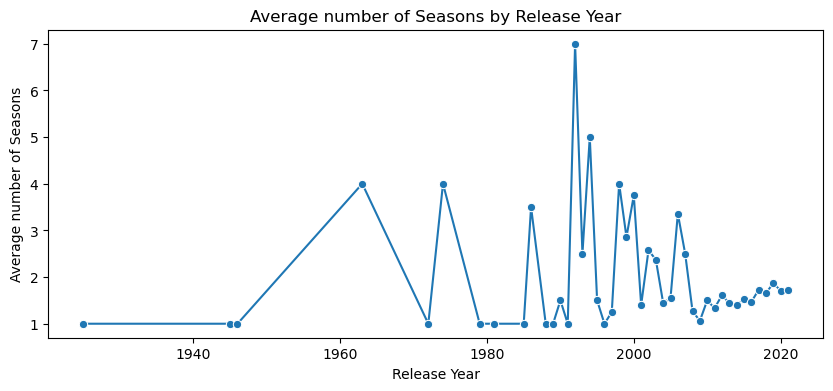

In [810]:
plt.figure(figsize=(10,4))
avg_sns_by_year = df_1.groupby('release_year') \
                        ['show_duration'].mean().reset_index()
sns.lineplot(data = avg_sns_by_year, x = 'release_year',
             y = 'show_duration', marker = 'o')
plt.title('Average number of Seasons by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average number of Seasons')

**8.Have movies in average gotten shorter over the year?**

In [812]:
movie_df = df.loc[df['type']=='Movie'].copy()
movie_df['movie_duration'] = movie_duration.values
avg_dur_by_years = movie_df.groupby('release_year')['movie_duration'].mean()

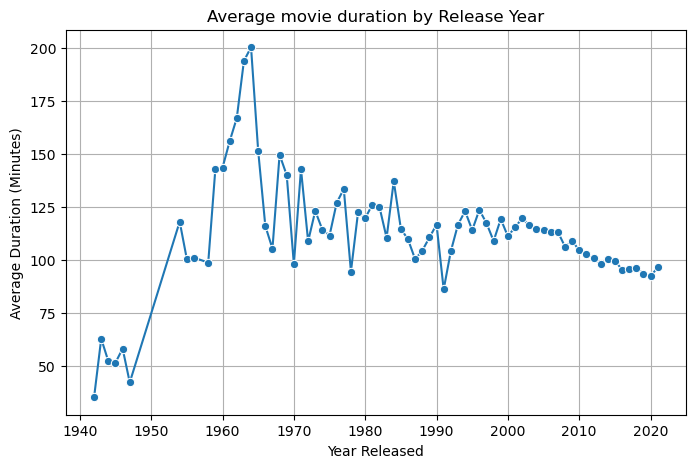

In [813]:
plt.figure(figsize=(8,5))
sns.lineplot(x = avg_dur_by_years.index, 
             y = avg_dur_by_years.values, marker = 'o')
plt.title('Average movie duration by Release Year')
plt.xlabel('Year Released')
plt.ylabel('Average Duration (Minutes)')
plt.grid(True)
plt.show()

**9What are the relationships between the numeric columns - Release Year, Duration, and Year Added?**

In [815]:
df_1 = df.copy()

In [816]:
df_1['duration_numeric'] = df_1['duration'].str.extract(r'(\d+)').astype(float)

<Figure size 700x700 with 0 Axes>

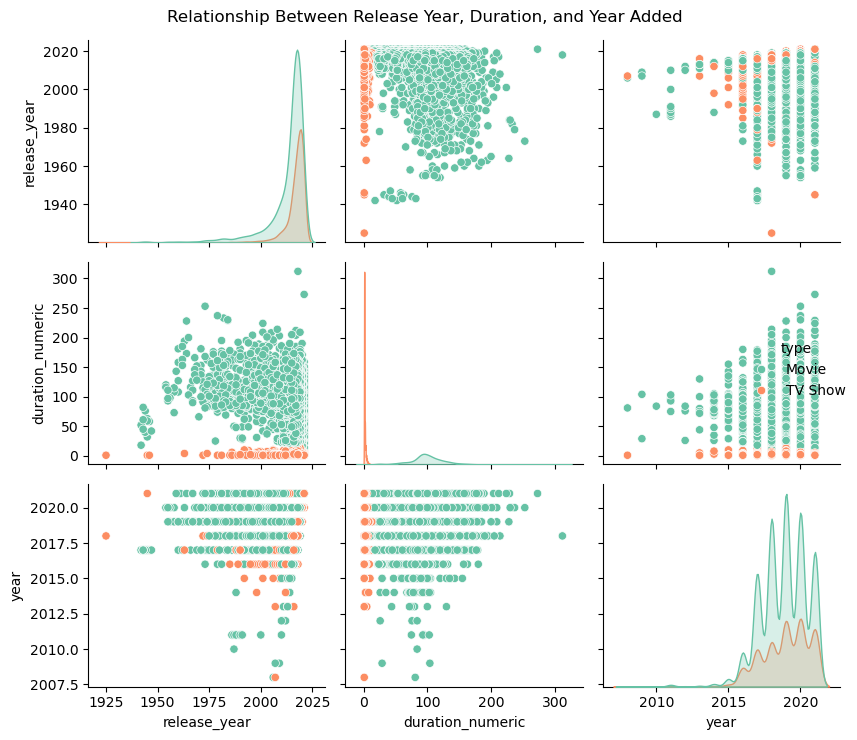

In [817]:
plt.figure(figsize=(7,7))
sns.pairplot(df_1, vars=['release_year','duration_numeric', 
                         'year'], hue = 'type', palette ='Set2')
plt.suptitle('Relationship Between Release Year, Duration, and Year Added')
plt.tight_layout()
plt.show()

***

# 4.Linear Regression 

**Predict: Movie Duration** \
**Features: type, release year, year added, rating**

In [821]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [822]:
# dummy variables for type and rating 
df_dummy = pd.get_dummies(movie_df[['rating','type']], drop_first=True)

In [823]:
# feature and label 
x = pd.concat([movie_df[['release_year','year']], df_dummy], axis=1)
y = movie_df['movie_duration']

In [824]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,test_size=0.2, random_state=21
)

In [825]:
# training
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [826]:
# Evaluation 
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

In [827]:
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.2f} minutes")
print(f"  MAE: {train_mae:.2f} minutes")

print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.2f} minutes")
print(f"  MAE: {test_mae:.2f} minutes")


Training Set:
  R² Score: 0.2060
  RMSE: 24.80 minutes
  MAE: 18.18 minutes

Test Set:
  R² Score: 0.2198
  RMSE: 26.51 minutes
  MAE: 19.37 minutes


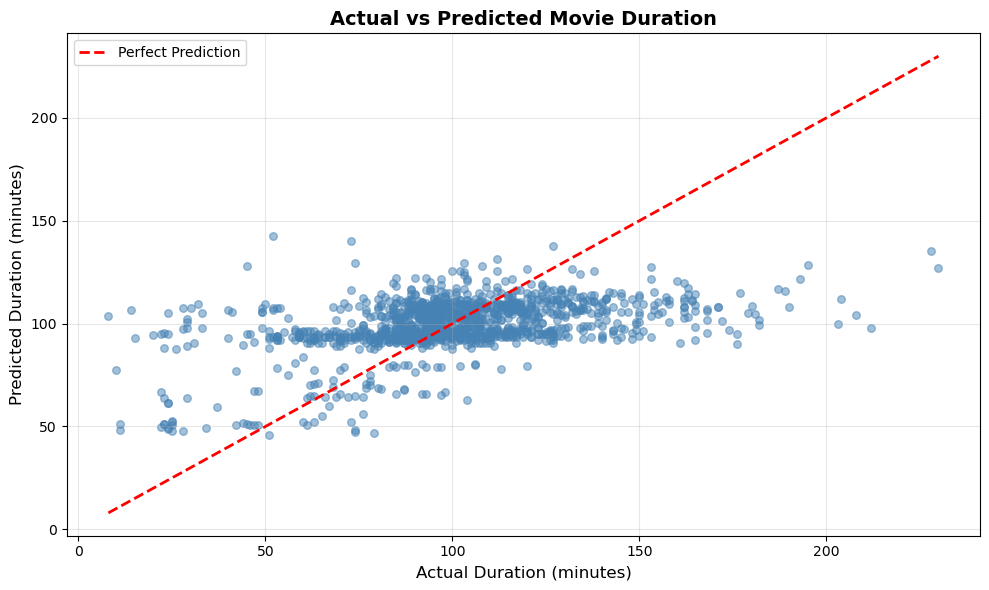

In [828]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=30, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Duration (minutes)', fontsize=12)
plt.ylabel('Predicted Duration (minutes)', fontsize=12)
plt.title('Actual vs Predicted Movie Duration', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()